# Notebook de obtención, limpieza y transformación de datos — Fase 2

**Proyecto:** Predicción de accidente cerebrovascular (*stroke*)

---

### ¿Qué es un *pipeline* de preprocesamiento?

Un *pipeline* es una secuencia ordenada de pasos por los que pasan los datos crudos hasta
quedar listos para analizar o modelar. En este notebook el flujo es:

**Obtener → Explorar → Limpiar → Transformar → Escalar → Validar**

Cada paso se implementa como una **función** reutilizable. Trabajar con funciones (en vez
de copiar y pegar código) hace el proceso más ordenado, más fácil de corregir y permite
reutilizar la misma lógica sobre cualquier columna sin reescribirla.

## Introducción

Según la Organización Mundial de la Salud, el accidente cerebrovascular es la segunda
causa de muerte a nivel mundial. Este conjunto de datos permite predecir la probabilidad
de que un paciente sufra un accidente cerebrovascular a partir de variables como el sexo,
la edad, distintas enfermedades y el estado de tabaquismo.

**Objetivo general (Fase 2).** Construir un *pipeline* reproducible que deje el *dataset*
limpio, codificado y escalado, listo para el modelado posterior.

**Objetivos específicos.**
- Obtener y explorar los datos verificando su estructura y calidad.
- Limpiar gestionando rigurosamente los valores nulos.
- Transformar las variables categóricas nominales con codificación One-Hot.
- Estandarizar las variables continuas.
- Validar técnicamente el resultado.

**Atributos:** `id`, `gender`, `age`, `hypertension`, `heart_disease`, `ever_married`,
`work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status` y la variable
objetivo `stroke` (1 = sufrió accidente cerebrovascular, 0 = no).

### Librerías utilizadas

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Cálculo numérico y manejo de arreglos. |
| `pandas` | Cargar y manipular la tabla de datos (el `DataFrame`). |
| `matplotlib` | Generar los gráficos (*boxplots*). |
| `sklearn.preprocessing` | Las herramientas de codificación (`LabelEncoder`, `OneHotEncoder`) y escalamiento (`StandardScaler`). |

`np.random.seed(42)` fija la semilla aleatoria: garantiza que cualquier proceso con azar
dé **siempre el mismo resultado**, lo que asegura la *reproducibilidad* exigida en la fase.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Reproducibilidad: fijamos la semilla aleatoria del entorno
np.random.seed(42)

%matplotlib inline

## 1. Obtención de los datos

**Qué hace este paso.** Lee el archivo CSV y lo carga en un `DataFrame` (la tabla con la
que trabajaremos).

**Por qué con una función.** Encapsulamos la lectura en `cargar_datos(ruta)` con un bloque
`try / except`. Así, si el archivo no existe, en lugar de un error técnico confuso, el
usuario recibe un mensaje claro indicando qué revisar. La función, además, imprime las
dimensiones cargadas, lo que sirve como primera verificación de que el archivo se leyó bien.

Es una función (def) que recibe un parámetro, ruta (el nombre del archivo), y se encarga de leer el CSV. El texto entre """...""" es el docstring: solo documentación, no se ejecuta. El bloque try/except maneja errores: intenta leer el archivo con pd.read_csv(ruta) y, si no lo encuentra, en vez de romperse muestra un mensaje claro de qué revisar (usando un f-string, que inserta el valor de ruta en el texto). Luego print informa el tamaño con df.shape[0] (filas) y df.shape[1] (columnas) —de ahí el "5110 filas y 12 columnas"— y return df entrega la tabla para usarla después. Al final, df = cargar_datos("...") llama a la función y guarda el resultado en df.

In [24]:
def cargar_datos(ruta):
    """
    Carga el conjunto de datos desde un archivo CSV.

    Parametros
    ----------
    ruta : str
        Ruta al archivo CSV de entrada.

    Retorna
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Lanza
    -----
    FileNotFoundError
        Si la ruta indicada no existe.
    """
    try:
        df = pd.read_csv(ruta)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontro el archivo '{ruta}'. "
            "Verifica que el CSV este en la misma carpeta del notebook."
        )
    print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df


df = cargar_datos("healthcare-dataset-stroke-data.csv")

Datos cargados: 5110 filas y 12 columnas.


Mostramos las primeras filas para confirmar visualmente que las columnas se cargaron correctamente:

Es una función (def) que recibe un parámetro, ruta (el nombre del archivo), y se encarga de leer el CSV. El texto entre """...""" es el docstring: solo documentación, no se ejecuta.
El bloque try/except maneja errores: intenta leer el archivo con pd.read_csv(ruta) y, si no lo encuentra, en vez de romperse muestra un mensaje claro de qué revisar (usando un f-string, que inserta el valor de ruta en el texto).
Luego print informa el tamaño con df.shape[0] (filas) y df.shape[1] (columnas) —de ahí el "5110 filas y 12 columnas"— y return df entrega la tabla para usarla después.
Al final, df = cargar_datos("...") llama a la función y guarda el resultado en df.

In [25]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Exploración inicial

**Qué hace este paso.** Antes de modificar nada, miramos el estado original de los datos.
Esto nos da la "línea base" contra la cual verificaremos después cada transformación.

La función `explorar_dataframe` reporta cuatro cosas:
1. **Dimensiones** (`shape`): cuántas filas y columnas hay.
2. **Tipos de datos** (`dtypes`): qué columnas son numéricas y cuáles son texto. Las de
   texto (`object`) son las que tendremos que codificar más adelante.
3. **Valores nulos** (`isnull().sum()`): cuántos datos faltan en cada columna. Aquí
   detectaremos que `bmi` tiene huecos.
4. **Estadísticos descriptivos** (`describe()`): media, mínimo, máximo, etc., de las
   variables numéricas, útil para detectar rangos raros o valores atípicos.

In [26]:
def explorar_dataframe(df):
    """Resumen exploratorio: dimensiones, tipos, nulos y estadisticos descriptivos."""
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("\nEstadisticos descriptivos (variables numericas):")
    return df.describe()


explorar_dataframe(df)

Dimensiones: (5110, 12)

Tipos de datos:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Valores nulos por columna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Estadisticos descriptivos (variables numericas):


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


También revisamos **cuántas categorías distintas** tiene cada variable de texto y cuántas
veces aparece cada una. Esto cumple dos funciones: detectar errores de tipeo o categorías
inesperadas, y conocer el orden en que aparecerán las categorías al codificarlas.

In [27]:
# Conteo de categorias en las variables nominales (control de calidad de entrada)
columnas_categoricas = ['gender', 'ever_married', 'work_type',
                        'Residence_type', 'smoking_status']
for col in columnas_categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


## 3. Limpieza de datos

Limpiar significa dejar los datos completos y consistentes. Tomamos dos decisiones, cada
una justificada técnicamente:

**a) Eliminar `id`.** Es un identificador único (un número distinto por paciente). No
contiene información que ayude a predecir el accidente cerebrovascular, así que lo
descartamos para que no introduzca ruido.

**b) Imputar `bmi` con la mediana.** `bmi` (índice de masa corporal) es la única columna
con valores faltantes. "Imputar" es rellenar esos huecos con un valor representativo.
Tenemos dos opciones:
- La **media** (promedio): se ve arrastrada por los valores extremos.
- La **mediana** (valor central): es **robusta** ante valores atípicos.

Como el `bmi` tiene valores atípicos (se ven en el *boxplot* del final), usar la mediana
evita que esos extremos sesguen el relleno. La función `imputar_nulos_numericos` permite
elegir la estrategia con un parámetro e informa cuántos nulos rellenó y con qué valor
(trazabilidad).

In [28]:
def imputar_nulos_numericos(df, columna, estrategia="mediana"):
    """
    Imputa los valores nulos de una columna numerica.

    Parametros
    ----------
    df : pd.DataFrame
    columna : str
        Columna numerica a imputar.
    estrategia : str
        'media' o 'mediana'.

    Retorna
    -------
    pd.DataFrame
        DataFrame con la columna imputada.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")
    n_nulos = int(df[columna].isnull().sum())
    if estrategia == "media":
        valor = df[columna].mean()
    elif estrategia == "mediana":
        valor = df[columna].median()
    else:
        raise ValueError("estrategia debe ser 'media' o 'mediana'")
    df = df.copy()
    df[columna] = df[columna].fillna(valor)
    print(f"'{columna}': {n_nulos} nulos imputados con la {estrategia} = {valor:.2f}")
    return df

**Antes** de limpiar, confirmamos dónde están los nulos:

In [29]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Eliminamos el identificador `id`:

In [30]:
df = df.drop(columns=['id'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Imputamos los nulos de `bmi` con la mediana:

In [31]:
df = imputar_nulos_numericos(df, "bmi", estrategia="mediana")

'bmi': 201 nulos imputados con la mediana = 28.10


**Después** de limpiar, verificamos que ya no quede ningún nulo (comprobación intermedia):

In [32]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## 4. Transformación: codificación One-Hot

Los modelos solo entienden números, no texto. Por eso hay que convertir las variables de
texto en números. Pero **cómo** las convertimos importa:

- `gender`, `ever_married`, `work_type`, `Residence_type` y `smoking_status` son
  **categóricas nominales**: sus categorías **no tienen un orden** ("Urbano" no es mayor ni
  menor que "Rural").
- Si simplemente les pusiéramos 0, 1, 2..., el modelo creería que existe un orden falso
  (que "2" vale más que "1"). Para evitarlo usamos **One-Hot Encoding**: cada categoría se
  convierte en su propia columna de 0 y 1.

Por ejemplo, la columna `Residence_type` se convierte en dos columnas:

| Residence_type | → | res_Rural | res_Urban |
|---|---|---|---|
| Urban | | 0 | 1 |
| Rural | | 1 | 0 |

Mantenemos el método visto en el curso —**`LabelEncoder` seguido de `OneHotEncoder`**— pero
lo encapsulamos en una sola función para no repetir el mismo bloque cinco veces.

### El patrón `fit` / `transform`

Casi todas las herramientas de scikit-learn funcionan en dos tiempos:
- **`fit`** = *aprender*: la herramienta mira los datos y guarda lo que necesita (por
  ejemplo, qué categorías existen).
- **`transform`** = *aplicar*: usa lo aprendido para convertir los datos.

Dentro de la función `codificar_one_hot` este patrón aparece **dos veces** (una con
`LabelEncoder` y otra con `OneHotEncoder`). Paso a paso, con el ejemplo `["Yes","No","Yes","No"]`:

1. **`le = preprocessing.LabelEncoder()`** — crea la herramienta que convierte texto en
   enteros. Aún está vacía.
2. **`le.fit(datos)`** — aprende las categorías y les asigna un número en orden alfabético:
   `"No" → 0`, `"Yes" → 1`.
3. **`le.transform(datos)`** — aplica lo aprendido → `[1, 0, 1, 0]`. Esto ya es *Label
   Encoding*.
4. **`ohe = preprocessing.OneHotEncoder()`** — crea la segunda herramienta, para One-Hot.
5. **`d = datos_codificados.reshape(-1, 1)`** — reorganiza los datos de una fila a una
   columna, porque el `OneHotEncoder` exige formato de tabla (2 dimensiones). El `-1`
   significa "calcula tú las filas" y el `1` significa "una columna".
6. **`ohe.fit(d)` y `ohe.transform(d).toarray()`** — expande cada entero en columnas
   binarias. `.toarray()` convierte el resultado a un arreglo normal.
7. **`pd.DataFrame(...)` + `pd.concat(...)`** — empaqueta las nuevas columnas con nombres
   legibles y las une al `DataFrame`, eliminando la columna original.

**Mejoras respecto al código original:** la función (a) asigna los nombres legibles
directamente, en lugar de renombrar por número de posición; (b) conserva el índice original
(`index=df.index`) para que la unión no desalinee filas; y (c) **valida** que la cantidad
de nombres coincida con la cantidad de categorías, avisando con un error claro si no.

In [33]:
def codificar_one_hot(df, columna, nombres_columnas):
    """
    Codifica una variable categorica nominal aplicando LabelEncoder y luego
    OneHotEncoder (patron fit/transform de scikit-learn).

    Parametros
    ----------
    df : pd.DataFrame
    columna : str
        Columna categorica a codificar.
    nombres_columnas : list[str]
        Nombres de las nuevas columnas binarias. El orden debe coincidir con el
        orden alfabetico de las categorias (criterio interno de LabelEncoder).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las nuevas columnas one-hot y sin la columna original.

    Lanza
    -----
    KeyError
        Si la columna no existe.
    ValueError
        Si el numero de nombres no coincide con el numero de categorias.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    # Paso 1-3: LabelEncoder aprende las categorias y las convierte a enteros
    le = preprocessing.LabelEncoder()
    datos = df[columna]
    le.fit(datos)
    datos_codificados = le.transform(datos)

    # Verificacion: los nombres deben corresponder a las categorias detectadas
    if len(nombres_columnas) != len(le.classes_):
        raise ValueError(
            f"Se esperaban {len(le.classes_)} nombres para '{columna}' "
            f"({list(le.classes_)}), pero se recibieron {len(nombres_columnas)}."
        )

    # Paso 4-6: OneHotEncoder expande los enteros a columnas binarias
    ohe = preprocessing.OneHotEncoder()
    d = datos_codificados.reshape(-1, 1)   # formato 2D requerido por el encoder
    ohe.fit(d)
    matriz = ohe.transform(d).toarray()

    # Paso 7: empaquetamos con nombres legibles y conservamos el indice original
    nuevas = pd.DataFrame(matriz, columns=nombres_columnas, index=df.index).astype(int)

    df = df.drop(columns=[columna]).reset_index(drop=True)
    nuevas = nuevas.reset_index(drop=True)
    return pd.concat([df, nuevas], axis=1)

### a. `gender`
Categorías (en orden alfabético): `Female`, `Male`, `Other` → tres columnas binarias.

In [34]:
df = codificar_one_hot(df, 'gender', ['gender_Female', 'gender_Male', 'gender_Other'])
df.head()

,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other
0,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0,1,0
1,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,1,0,0
2,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1,0
3,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1,0,0
4,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,0,0


### b. `ever_married`
Categorías: `No`, `Yes` → dos columnas binarias.

In [35]:
df = codificar_one_hot(df, 'ever_married', ['married_No', 'married_Yes'])
df.head()

,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,married_No,married_Yes
0,67.0,0,1,Private,Urban,228.69,36.6,formerly smoked,1,0,1,0,0,1
1,61.0,0,0,Self-employed,Rural,202.21,28.1,never smoked,1,1,0,0,0,1
2,80.0,0,1,Private,Rural,105.92,32.5,never smoked,1,0,1,0,0,1
3,49.0,0,0,Private,Urban,171.23,34.4,smokes,1,1,0,0,0,1
4,79.0,1,0,Self-employed,Rural,174.12,24.0,never smoked,1,1,0,0,0,1


### c. `work_type`
Categorías (orden alfabético): `Govt_job`, `Never_worked`, `Private`, `Self-employed`,
`children` → cinco columnas binarias.

In [36]:
df = codificar_one_hot(
    df, 'work_type',
    ['work_Govt', 'work_Never', 'work_Private', 'work_Self', 'work_children']
)
df.head()

,age,hypertension,heart_disease,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,married_No,married_Yes,work_Govt,work_Never,work_Private,work_Self,work_children
0,67.0,0,1,Urban,228.69,36.6,formerly smoked,1,0,1,0,0,1,0,0,1,0,0
1,61.0,0,0,Rural,202.21,28.1,never smoked,1,1,0,0,0,1,0,0,0,1,0
2,80.0,0,1,Rural,105.92,32.5,never smoked,1,0,1,0,0,1,0,0,1,0,0
3,49.0,0,0,Urban,171.23,34.4,smokes,1,1,0,0,0,1,0,0,1,0,0
4,79.0,1,0,Rural,174.12,24.0,never smoked,1,1,0,0,0,1,0,0,0,1,0


### d. `Residence_type`
Categorías: `Rural`, `Urban` → dos columnas binarias.

In [37]:
df = codificar_one_hot(df, 'Residence_type', ['res_Rural', 'res_Urban'])
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,married_No,married_Yes,work_Govt,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban
0,67.0,0,1,228.69,36.6,formerly smoked,1,0,1,0,0,1,0,0,1,0,0,0,1
1,61.0,0,0,202.21,28.1,never smoked,1,1,0,0,0,1,0,0,0,1,0,1,0
2,80.0,0,1,105.92,32.5,never smoked,1,0,1,0,0,1,0,0,1,0,0,1,0
3,49.0,0,0,171.23,34.4,smokes,1,1,0,0,0,1,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,never smoked,1,1,0,0,0,1,0,0,0,1,0,1,0


### e. `smoking_status`
Categorías (orden alfabético): `Unknown`, `formerly smoked`, `never smoked`, `smokes` →
cuatro columnas binarias. Mantenemos `Unknown` como categoría propia: en este *dataset*
representa información no declarada, no un valor a imputar.

In [38]:
df = codificar_one_hot(
    df, 'smoking_status',
    ['smoke_Unknown', 'smoke_formerly', 'smoke_never', 'smoke_smokes']
)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,married_No,...,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban,smoke_Unknown,smoke_formerly,smoke_never,smoke_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
1,61.0,0,0,202.21,28.1,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0


## 5. Escalamiento (estandarización)

**Qué es.** Estandarizar (*z-score*) transforma una variable para que tenga **media 0 y
desviación estándar 1**, mediante la fórmula:

$$ z = \frac{x - \mu}{\sigma} $$

donde $\mu$ es la media y $\sigma$ la desviación estándar de la columna.

**Por qué.** Variables como `age` (1–90) y `avg_glucose_level` (55–270) están en escalas muy
distintas. Algunos modelos (KNN, SVM, regresión regularizada) se basan en distancias y darían
más peso a la variable de números más grandes solo por su escala. Estandarizar las pone en
condiciones comparables.

**Qué NO escalamos.** Solo estandarizamos las variables **continuas** (`age`,
`avg_glucose_level`, `bmi`). No tocamos las columnas binarias (las one-hot, `hypertension`,
`heart_disease`) ni la variable objetivo `stroke`, porque estandarizar valores 0/1 o el
*target* distorsiona su interpretación. Esta es una corrección importante frente a aplicar
el escalador a toda la tabla.

La función devuelve también el `scaler` ajustado, por si más adelante hay que aplicar la
misma transformación a datos nuevos.

In [39]:
def escalar_caracteristicas(df, columnas):
    """
    Estandariza (z-score) las columnas indicadas con StandardScaler.

    Retorna el DataFrame transformado y el objeto scaler ajustado (para poder
    reutilizarlo sobre datos nuevos sin recalcular las estadisticas).
    """
    df = df.copy()
    scaler = StandardScaler()
    df[columnas] = scaler.fit_transform(df[columnas])
    return df, scaler

Tras escalar, la media debe quedar ≈ 0 y la desviación estándar ≈ 1:

In [40]:
columnas_continuas = ['age', 'avg_glucose_level', 'bmi']
df, scaler = escalar_caracteristicas(df, columnas_continuas)
df[columnas_continuas].describe()

,age,avg_glucose_level,bmi
count,5.110000e+03,5.110000e+03,5.110000e+03
mean,5.005781e-17,1.001156e-16,-4.449583e-17
std,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908261e+00,-1.126958e+00,-2.411027e+00
25%,-8.061152e-01,-6.383223e-01,-6.575089e-01
50%,7.843218e-02,-3.149945e-01,-9.898092e-02
75%,7.860701e-01,1.754080e-01,5.115031e-01
max,1.714845e+00,3.657145e+00,8.928390e+00


## 6. Validación técnica y verificación del código

Verificar significa demostrar, con evidencia, que el resultado es correcto. La función
`validar_dataset` ejecuta varias comprobaciones y usa `assert`: si una condición no se
cumple, el notebook se detiene con un error, dejando constancia de la falla.

Comprobamos:
1. **Integridad** — que no queden valores nulos.
2. **Consistencia** — que todas las columnas sean numéricas (no quedó texto sin codificar).
3. **Coherencia** — que cada grupo one-hot sume exactamente 1 por fila: cada paciente
   pertenece a **una sola** categoría dentro de cada variable.
4. **Duplicados** — cuántas filas repetidas hay.
5. **Dimensiones** — la forma final de la tabla.

In [41]:
def validar_dataset(df, grupos_one_hot=None):
    """
    Comprueba integridad, consistencia y coherencia del dataset final.
    Lanza AssertionError si alguna comprobacion falla.
    """
    print("VALIDACION DEL DATASET FINAL")
    print("-" * 45)

    # 1. Integridad: sin valores nulos
    nulos = int(df.isnull().sum().sum())
    assert nulos == 0, f"Quedan {nulos} valores nulos."
    print(f"[OK] Sin valores nulos (total = {nulos})")

    # 2. Consistencia: todas las columnas son numericas
    no_numericas = df.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not no_numericas, f"Columnas no numericas: {no_numericas}"
    print("[OK] Todas las columnas son numericas")

    # 3. Coherencia: cada grupo one-hot suma 1 por fila (una sola categoria activa)
    if grupos_one_hot:
        for nombre, cols in grupos_one_hot.items():
            suma = df[cols].sum(axis=1)
            assert (suma == 1).all(), f"El grupo '{nombre}' no suma 1 en todas las filas."
            print(f"[OK] Grupo one-hot '{nombre}' coherente")

    # 4. Duplicados
    dup = int(df.duplicated().sum())
    print(f"[INFO] Filas duplicadas: {dup}")

    # 5. Dimensiones finales
    print(f"[INFO] Dimensiones finales: {df.shape}")
    return True


grupos = {
    'gender': ['gender_Female', 'gender_Male', 'gender_Other'],
    'ever_married': ['married_No', 'married_Yes'],
    'work_type': ['work_Govt', 'work_Never', 'work_Private', 'work_Self', 'work_children'],
    'Residence_type': ['res_Rural', 'res_Urban'],
    'smoking_status': ['smoke_Unknown', 'smoke_formerly', 'smoke_never', 'smoke_smokes'],
}
validar_dataset(df, grupos)

VALIDACION DEL DATASET FINAL
---------------------------------------------
[OK] Sin valores nulos (total = 0)
[OK] Todas las columnas son numericas
[OK] Grupo one-hot 'gender' coherente
[OK] Grupo one-hot 'ever_married' coherente
[OK] Grupo one-hot 'work_type' coherente
[OK] Grupo one-hot 'Residence_type' coherente
[OK] Grupo one-hot 'smoking_status' coherente
[INFO] Filas duplicadas: 0
[INFO] Dimensiones finales: (5110, 22)


True

### Pruebas de las funciones (casos normal, límite y excepciones)

Además de validar el *dataset*, probamos la función de codificación en tres escenarios,
tal como pide la rúbrica:
- **Caso normal:** una columna pequeña y conocida; verificamos que produzca el número
  correcto de columnas y que cada fila tenga una sola categoría activa.
- **Excepción 1:** se pasa una cantidad equivocada de nombres → debe lanzar `ValueError`.
- **Excepción 2:** se pide codificar una columna inexistente → debe lanzar `KeyError`.

In [42]:
# --- Caso normal ---
prueba = pd.DataFrame({'color': ['rojo', 'azul', 'rojo', 'verde']})
res = codificar_one_hot(prueba, 'color', ['azul', 'rojo', 'verde'])
assert res.shape == (4, 3), "Numero de columnas inesperado."
assert (res.sum(axis=1) == 1).all(), "Cada fila debe tener una sola categoria activa."
print("[OK] Caso normal: codificacion correcta")

# --- Excepcion 1: numero de nombres incorrecto ---
try:
    codificar_one_hot(prueba, 'color', ['azul', 'rojo'])
except ValueError as e:
    print(f"[OK] Excepcion capturada (nombres): {e}")

# --- Excepcion 2: columna inexistente ---
try:
    codificar_one_hot(prueba, 'inexistente', ['x'])
except KeyError as e:
    print(f"[OK] Excepcion capturada (columna): {e}")

[OK] Caso normal: codificacion correcta
[OK] Excepcion capturada (nombres): Se esperaban 3 nombres para 'color' (['azul', 'rojo', 'verde']), pero se recibieron 2.
[OK] Excepcion capturada (columna): "La columna 'inexistente' no existe en el DataFrame."


### Visualización de control

El *boxplot* de las variables continuas ya estandarizadas confirma que quedaron centradas
alrededor de 0 y en una escala comparable. Los puntos alejados de las cajas son los valores
atípicos que motivaron usar la mediana en la imputación.

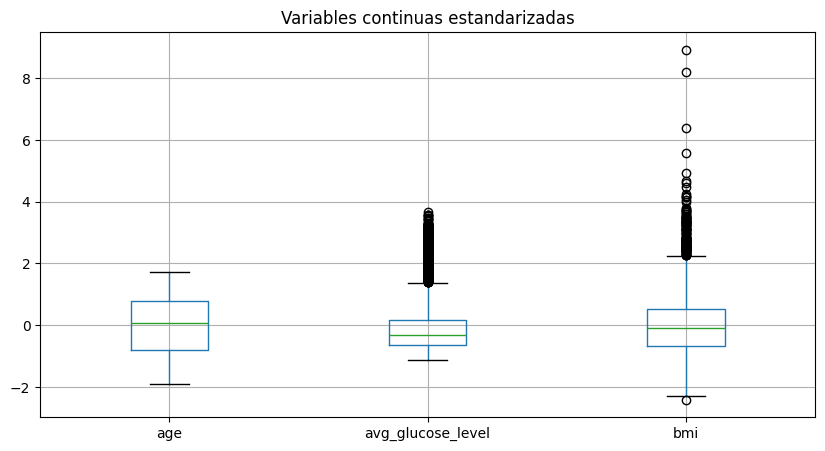

In [43]:
df[columnas_continuas].boxplot(figsize=(10, 5))
plt.title("Variables continuas estandarizadas")
plt.show()

Vista final del *dataset* completamente preprocesado:

In [44]:
print("Dataset final:", df.shape)
df.head()

Dataset final: (5110, 22)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,married_No,...,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban,smoke_Unknown,smoke_formerly,smoke_never,smoke_smokes
0,1.051434,0,1,2.706375,1.005086,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
1,0.786070,0,0,2.121559,-0.098981,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1.626390,0,1,-0.005028,0.472536,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,0.255342,0,0,1.437358,0.719327,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,1.582163,1,0,1.501184,-0.631531,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0


## Conclusiones y trazabilidad

El *pipeline* dejó el *dataset* sin valores nulos, con todas las variables en formato
numérico y las continuas estandarizadas. Cada paso se implementó como una función
documentada y reutilizable (`cargar_datos`, `explorar_dataframe`, `imputar_nulos_numericos`,
`codificar_one_hot`, `escalar_caracteristicas`, `validar_dataset`), garantizando un flujo
modular, reproducible y verificable.

**Trazabilidad con el repositorio (F2):** este notebook se ubica en la carpeta `F2/` del
repositorio GitHub; el `README` documenta las dependencias (`numpy`, `pandas`,
`scikit-learn`, `matplotlib`) y las instrucciones de ejecución. El historial de *commits*
refleja el avance del *pipeline* descrito en el informe técnico de la Fase 2.